# Section 1: Fundamentals
Toolkit for Physical Reservoir Computer System Identification.
Tests in this section confirm the DUT is nonlinear and establish the safe operating region.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import json, os
from prc_toolkit.config import FS, DT, V_MAX, RESULTS_DIR, SEED
from prc_toolkit.dut.base import to_input_seq
from prc_toolkit.dut.factory import make_dut, prepare_input
from prc_toolkit.dut.ag2s_nwn import RECOMMENDED_PARAMS   # for switching to Ag2S-NWN
from prc_toolkit.signals.generators import multisine, sine_sweep
from prc_toolkit.analysis.lissajous import lissajous_response
from prc_toolkit.utils.settling import run_until_settled

In [2]:
# ── DUT Parameters ────────────────────────────────────────
N_X          = 50     # Reservoir size
N_H          = 5      # Number of output electrodes
ALPHA        = 0.3    # Leaking rate
SPEC_RADIUS  = 1.1    # Spectral radius ρ(W)
SIGMA_PROC   = 0.01   # Process noise gain (set 0.0 to disable)
SIGMA_MEAS   = 0.005  # Measurement noise gain (set 0.0 to disable)

# ── Safe Region Sweep Parameters ───────────────────────────
N_AMP_STEPS  = 10     # Number of amplitude steps from -20 dB to 0 dB
SWEEP_SETTLE_PERIODS = 2   # Sine periods driven but discarded (let the transient settle)
SWEEP_RECORD_PERIODS = 3   # Sine periods recorded after settling

# ── Distortion / Noise Analysis Parameters ──────────────────
N_PERIODS    = 8      # Number of multisine periods to record
PERIOD_DURATION = 1.0 # Duration of one period in seconds (must be integer for FFT bin alignment)

# ── DUT selection: "liesn" (default), "ag2s_nwn", or "hardware" ─────────
# "hardware" is only supported for Section 1.3 -- Sections 1.1 and 1.2 are
# demonstration-only and will raise a clear error if run with it.
DUT_MODEL = "liesn"
# DUT_MODEL = "ag2s_nwn"
# DUT_MODEL = "hardware"

# Pre-recorded output CSVs are loaded from here when DUT_MODEL == "hardware".
# Defaults to the committed demo dataset so hardware mode works without real
# hardware attached; point this at data/hardware/outputs once you've recorded
# real data via 00_hardware_signals.ipynb.
HARDWARE_DATA_PATH = "data/demo/hardware_outputs"

# Set True (with DUT_MODEL="liesn") to regenerate data/demo/hardware_outputs/,
# then set back to False.
SAVE_DEMO_HARDWARE_DATA = False

# LIESN_PARAMS is always serialized to results/section1_results.json for
# notebooks 02-04 to reuse as their own default LI-ESN config, regardless of
# which DUT_MODEL this notebook actually runs against.
LIESN_PARAMS = dict(
    N_x=N_X, N_h=N_H, alpha=ALPHA,
    spectral_radius=SPEC_RADIUS,
    sigma_process=SIGMA_PROC,
    sigma_measure=SIGMA_MEAS,
    seed=SEED,
)

# DUT_PARAMS matches DUT_MODEL. Default: LIESN_PARAMS above.
# For Ag2S-NWN, set DUT_PARAMS = RECOMMENDED_PARAMS.
DUT_PARAMS = LIESN_PARAMS
# DUT_PARAMS = RECOMMENDED_PARAMS  # Uncomment to switch to Ag2S-NWN

assert DUT_MODEL in ("liesn", "ag2s_nwn", "hardware"), (
    f"DUT_MODEL '{DUT_MODEL}' is not supported in this notebook. "
    f"Supported values: 'liesn', 'ag2s_nwn', 'hardware'."
)

# ── Instantiate DUT ─────────────────────────────────────
dut = make_dut(DUT_MODEL, DUT_PARAMS)

> **Note:** Sections 1.1 and 1.2 are for demonstration purposes only using
> simulated DUT models — they do not support `DUT_MODEL = "hardware"` and
> will raise a clear error if you try. Section 1.3 (Distortion and Noise
> Analysis) supports hardware mode; see `00_hardware_signals.ipynb` for
> recording instructions.

## 1.1 Disqualifying Simple Devices

Visual check. The operator applies a slow DC voltage sweep and AC sweeps at multiple
frequencies to the DUT and plots the resulting I/V or V/V curves. Compare against
the signatures in Table 2 (wire, resistor, capacitor, inductor, diode).

For simulation, this test is bypassed — the LI-ESN is known to be nonlinear by construction.
In hardware, inspect the output of this cell manually before proceeding.

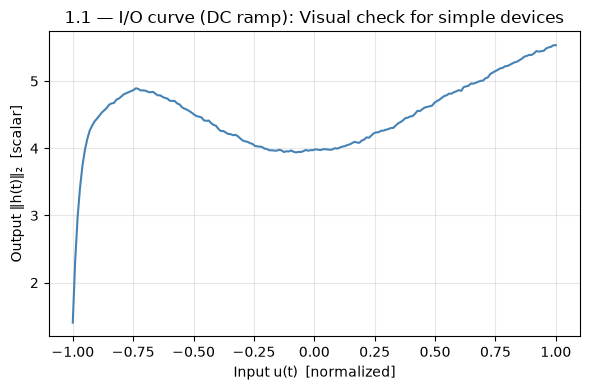

1.1 Linear device check: Not a wire or resistor (R²=0.2461). Proceeding.
OPERATOR: Inspect the I/O curve above.
Confirm the DUT is NOT a wire, resistor, capacitor, inductor, or diode.
(See Table 2 in the paper for expected signatures of each simple device.)
(Capacitor/inductor checks run automatically at the end of Section 1.3.1.)


In [3]:
# ── 1.1 Simple Device Disqualification ────────────────────────
if DUT_MODEL == "hardware":
    print("Section 1.1 is demonstration-only and does not support DUT_MODEL='hardware'. Skipping.")
else:
    # For simulation: generate a slow DC ramp and plot h vs u to confirm
    # the DUT is not a wire or resistor.

    ramp_duration = 2.0
    T_ramp = int(ramp_duration * FS)
    u_ramp = np.linspace(-V_MAX, V_MAX, T_ramp)

    dut.reset()
    H_ramp = dut.run(to_input_seq(u_ramp))   # reshape (T,) -> (T,1) for DUT interface
    h_ramp_scalar = np.linalg.norm(H_ramp, axis=1)  # scalar: L2 norm of electrode vector

    fig, ax = plt.subplots(figsize=(6, 4))
    ax.plot(u_ramp, h_ramp_scalar, color='steelblue', lw=1.5)
    ax.set_xlabel("Input u(t)  [normalized]")
    ax.set_ylabel("Output ‖h(t)‖₂  [scalar]")
    ax.set_title("1.1 — I/O curve (DC ramp): Visual check for simple devices")
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

    # ── 1.1 Wire / resistor check (automated) ────────────────
    slope, intercept = np.polyfit(u_ramp, h_ramp_scalar, 1)
    h_fit = slope * u_ramp + intercept
    ss_res = np.sum((h_ramp_scalar - h_fit)**2)
    ss_tot = np.sum((h_ramp_scalar - h_ramp_scalar.mean())**2)
    r2_linear = 1 - ss_res / (ss_tot + 1e-12)

    if r2_linear > 0.99 and abs(slope - 1.0) < 0.05 and abs(intercept) < 0.05:
        print(f"1.1 Wire check: LIKELY A WIRE (R²={r2_linear:.4f}, slope≈1, intercept≈0). Do not proceed.")
    elif r2_linear > 0.99:
        print(f"1.1 Resistor check: LIKELY A RESISTOR (R²={r2_linear:.4f}, slope={slope:.3f}). Do not proceed.")
    else:
        print(f"1.1 Linear device check: Not a wire or resistor (R²={r2_linear:.4f}). Proceeding.")

    # Diode check is VISUAL ONLY — inspect the curve shape against Table 2 in the paper.
    # A diode shows exponential-like forward conduction and near-zero reverse current
    # with sharp breakdown. If the curve resembles a diode, do not proceed.
    # Capacitor/inductor checks require the multisine FFT data from Section 1.3.1 --
    # run that section first; the checks are appended to the end of its code cell.
    print("OPERATOR: Inspect the I/O curve above.")
    print("Confirm the DUT is NOT a wire, resistor, capacitor, inductor, or diode.")
    print("(See Table 2 in the paper for expected signatures of each simple device.)")
    print("(Capacitor/inductor checks run automatically at the end of Section 1.3.1.)")

## 1.2 Safe Region of Operation

A pure sine is applied at increasing amplitudes (in dB steps from -20 dB to 0 dB
relative to V_MAX). At each step, the Response Lissajous Plot (dh/dt vs h(t)) is
shown overlaid with all previous steps, colored by amplitude.

**Operator instruction:** Inspect the LP for amplitude crossings (trajectories
intersecting themselves across different amplitude steps). The onset of crossing
marks the boundary of safe operation. Record V_safe manually in the cell below.

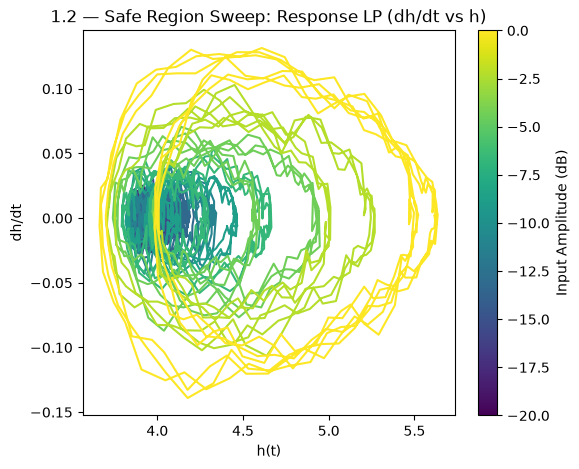

In [4]:
# ── 1.2 Safe Region Sweep ────────────────────────────────
if DUT_MODEL == "hardware":
    print("Section 1.2 is demonstration-only and does not support DUT_MODEL='hardware'. Skipping.")
else:
    # I/O convention: u is scalar (float), h is vector (N_h,).
    # This test uses the scalar output: h_scalar = ‖h‖₂.
    # Each amplitude step drives the DUT for SWEEP_SETTLE_PERIODS periods
    # (discarded) then SWEEP_RECORD_PERIODS periods (recorded) -- avoids the
    # long transient tail that makes the LP hard to read (same fix as the
    # visual fingerprint sweep in notebook 02, Section 2.1).
    sweep_duration = float(SWEEP_SETTLE_PERIODS + SWEEP_RECORD_PERIODS)
    n_settle_sweep = int(SWEEP_SETTLE_PERIODS * FS)

    sweep = sine_sweep(
        duration=sweep_duration,
        amplitude=V_MAX,
        n_steps=N_AMP_STEPS,
        fs=FS
    )

    sweep_results = []
    for amp_linear, u_step in sweep:
        amp_dB = 20 * np.log10(amp_linear / V_MAX)  # dB relative to V_MAX

        dut.reset()
        H_full = dut.run(to_input_seq(u_step))
        H_step = H_full[n_settle_sweep:]

        h_scalar = np.linalg.norm(H_step, axis=1)  # shape (T_record,) — scalar output

        sweep_results.append({
            'amplitude_dB': amp_dB,
            'h_scalar': h_scalar,
        })

    # ── Response LP only (dh/dt vs h), colored by amplitude in dB ────────
    amplitudes_dB = np.array([r['amplitude_dB'] for r in sweep_results])
    cmap = plt.get_cmap("viridis")
    norm_color = plt.Normalize(vmin=amplitudes_dB.min(), vmax=amplitudes_dB.max())

    fig_safe, ax_safe = plt.subplots(figsize=(6, 5))
    for r in sweep_results:
        lissajous_response(r['h_scalar'], color=cmap(norm_color(r['amplitude_dB'])), ax=ax_safe)
    ax_safe.set_title("1.2 — Safe Region Sweep: Response LP (dh/dt vs h)")

    sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm_color)
    sm.set_array([])
    fig_safe.colorbar(sm, ax=ax_safe, label="Input Amplitude (dB)")
    plt.show()

In [5]:
# ── Set V_safe manually after inspecting the LP above ───────────
# Increase this value toward 1.0 until crossings appear, then step back.

V_SAFE = 0.8   # ← EDIT THIS based on visual inspection of the LP above

print(f"V_safe set to: {V_SAFE:.3f}  ({20*np.log10(V_SAFE):.1f} dB re V_MAX)")
print("This value will be saved to results and used by later notebooks.")

V_safe set to: 0.800  (-1.9 dB re V_MAX)
This value will be saved to results and used by later notebooks.


## 1.3 Nonlinear System Analysis

A multisine input u(t) = sin(2π·1·t) + sin(2π·3·t) + sin(2π·7·t) + sin(2π·11·t)
is applied at amplitude V_safe. The FFT output is decomposed into:

- H_linear: energy at the input frequencies f = 1, 3, 7, 11 Hz
- H_odd:    energy at odd intermodulation products f = 5, 9 Hz
- H_even:   energy at even intermodulation products f = 0, 2, 4, 6, 8, 10 Hz

The noise floor is estimated by comparing FFT spectra across multiple periods.
A signal that varies from period to period is noise; one that remains coherent is distortion.

In [6]:
# ── Hardware I/O helpers ─────────────────────────────────
# Plain stdlib csv module
# dependency (see 04_benchmarks.ipynb's sunspot loader for precedent).
import csv
from pathlib import Path

def load_hardware_output(filename: str) -> np.ndarray:
    """
    Load a pre-recorded hardware output CSV from HARDWARE_DATA_PATH.

    Expected format:
      - Header row with column names h0, h1, h2, ... (one per output electrode)
      - One row per timestep
      - Values are floating-point voltage readings

    Returns H: array, shape (T, N_h).

    If the file is not found, raises FileNotFoundError with a helpful message
    directing the operator to 00_hardware_signals.ipynb for recording instructions.
    """
    path = Path(HARDWARE_DATA_PATH) / filename
    if not path.exists():
        raise FileNotFoundError(
            f"Hardware output file not found: {path}\n"
            f"Run 00_hardware_signals.ipynb and follow the recording instructions "
            f"to generate this file before running this notebook."
        )
    with open(path, newline="") as f:
        reader = csv.reader(f)
        next(reader)  # header row (h0, h1, ...)
        rows = [[float(v) for v in row] for row in reader]
    return np.array(rows, dtype=float)


DEMO_DATA_PATH = Path("data/demo/hardware_outputs")

def save_hardware_demo(filename: str, H: np.ndarray):
    """
    Save H into the committed demo dataset (data/demo/hardware_outputs/) so
    that DUT_MODEL="hardware" works out of the box without real hardware.
    No-op unless SAVE_DEMO_HARDWARE_DATA = True. Regenerate the demo dataset
    by re-running this notebook with DUT_MODEL="liesn" and
    SAVE_DEMO_HARDWARE_DATA=True.
    """
    if not SAVE_DEMO_HARDWARE_DATA:
        return
    DEMO_DATA_PATH.mkdir(parents=True, exist_ok=True)
    header = [f"h{i}" for i in range(H.shape[1])]
    with open(DEMO_DATA_PATH / filename, "w", newline="") as f:
        writer = csv.writer(f)
        writer.writerow(header)
        writer.writerows(H.tolist())


run_until_settled: max_samples reached before settling criterion met (eps=0.0001). Proceeding with unsettled state. Consider increasing max_samples or adjusting input.


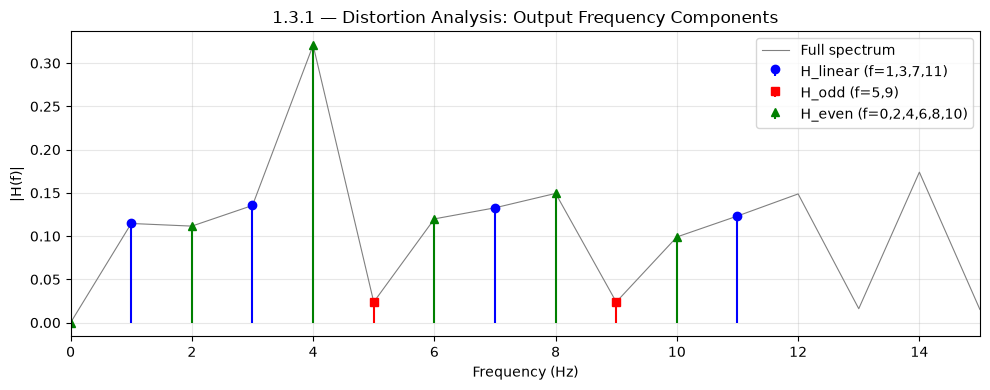

H_linear power: 0.0643  (22.0% of total)
H_odd power:    0.0011  (0.4% of total)
H_even power:   0.1618  (55.5% of total)
1.1 Capacitor/Inductor check: Not a capacitor or inductor (log-log slope=0.035). Proceeding.


In [7]:
# ── 1.3.1 Distortion Analysis ──────────────────────────
# I/O convention:
#   u is scalar (float), shape (T,)
#   h used as scalar: h_scalar = ‖h‖₂, shape (T,)
# Requires: period duration = integer seconds so multisine freqs hit exact FFT bins.

T_period = int(PERIOD_DURATION * FS)  # samples per period
total_duration = N_PERIODS * PERIOD_DURATION

u_ms = multisine(duration=total_duration, amplitude=V_SAFE, fs=FS)

# --- Data collection ---
if DUT_MODEL == "hardware":
    H_ms = load_hardware_output("section1_multisine.csv")
else:
    dut.reset()
    run_until_settled(dut, to_input_seq(u_ms))
    H_ms = dut.run(to_input_seq(u_ms))  # shape (T_total, N_h)
    save_hardware_demo("section1_multisine.csv", H_ms)
h_ms = np.linalg.norm(H_ms, axis=1)  # scalar output, shape (T_total,)

# ── FFT over one period (use last period for steady state) ─────────
h_period = h_ms[-T_period:]
h_period = h_period - h_period.mean()   # remove DC offset before FFT
# Note: ‖h‖₂ is always non-negative, so h_scalar has a large positive mean.
# Mean subtraction isolates the AC dynamics for spectral analysis.
freqs = np.fft.rfftfreq(T_period, d=DT)   # Hz
H_fft = np.abs(np.fft.rfft(h_period)) / T_period

# ── Classify frequency bins ─────────────────────────────
# Bin index k corresponds to frequency k * (FS / T_period) = k * 1 Hz (since PERIOD_DURATION=1s)
f_linear = [1, 3, 7, 11]    # input frequencies
f_odd    = [5, 9]            # odd intermodulation products
f_even   = [0, 2, 4, 6, 8, 10]  # even intermodulation products

def get_bins(freq_list, freqs):
    return [np.argmin(np.abs(freqs - f)) for f in freq_list]

bins_lin  = get_bins(f_linear, freqs)
bins_odd  = get_bins(f_odd, freqs)
bins_even = get_bins(f_even, freqs)

# ── Plot ──────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(freqs, H_fft, color='gray', lw=0.8, label='Full spectrum')
ax.stem(freqs[bins_lin],  H_fft[bins_lin],  linefmt='b-', markerfmt='bo',
        basefmt=' ', label='H_linear (f=1,3,7,11)')
ax.stem(freqs[bins_odd],  H_fft[bins_odd],  linefmt='r-', markerfmt='rs',
        basefmt=' ', label='H_odd (f=5,9)')
ax.stem(freqs[bins_even], H_fft[bins_even], linefmt='g-', markerfmt='g^',
        basefmt=' ', label='H_even (f=0,2,4,6,8,10)')
ax.set_xlabel("Frequency (Hz)")
ax.set_ylabel("|H(f)|")
ax.set_title("1.3.1 — Distortion Analysis: Output Frequency Components")
ax.set_xlim([0, 15])
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# ── Summary ────────────────────────────────────────────
H_linear_power = np.sum(H_fft[bins_lin]**2)
H_odd_power    = np.sum(H_fft[bins_odd]**2)
H_even_power   = np.sum(H_fft[bins_even]**2)
total_power    = np.sum(H_fft**2)

print(f"H_linear power: {H_linear_power:.4f}  ({100*H_linear_power/total_power:.1f}% of total)")
print(f"H_odd power:    {H_odd_power:.4f}  ({100*H_odd_power/total_power:.1f}% of total)")
print(f"H_even power:   {H_even_power:.4f}  ({100*H_even_power/total_power:.1f}% of total)")

# ── 1.1 Capacitor / Inductor check (requires 1.3.1 FFT data) ─────────
# For a capacitor: |H(f)| / |U(f)| ∝ f  (impedance 1/2πfC, so output ∝ f)
# For an inductor: |H(f)| / |U(f)| ∝ 1/f
# Test using the 4 linear frequency bins (f=1,3,7,11 Hz).
# Input multisine has equal amplitude at each frequency by construction,
# so |U(f)| is approximately constant and we just check |H(f)| vs f.

f_vals  = np.array([1.0, 3.0, 7.0, 11.0])
h_at_f  = H_fft[bins_lin]   # |H| at linear frequencies

# Fit log|H| vs log(f): slope≈+1 → capacitor, slope≈-1 → inductor
log_f = np.log(f_vals)
log_h = np.log(h_at_f + 1e-30)
slope_cap, _ = np.polyfit(log_f, log_h, 1)

if abs(slope_cap - 1.0) < 0.3:
    print(f"1.1 Capacitor check: LIKELY A CAPACITOR (log-log slope={slope_cap:.3f}≈+1). Do not proceed.")
elif abs(slope_cap + 1.0) < 0.3:
    print(f"1.1 Inductor check: LIKELY AN INDUCTOR (log-log slope={slope_cap:.3f}≈-1). Do not proceed.")
else:
    print(f"1.1 Capacitor/Inductor check: Not a capacitor or inductor (log-log slope={slope_cap:.3f}). Proceeding.")

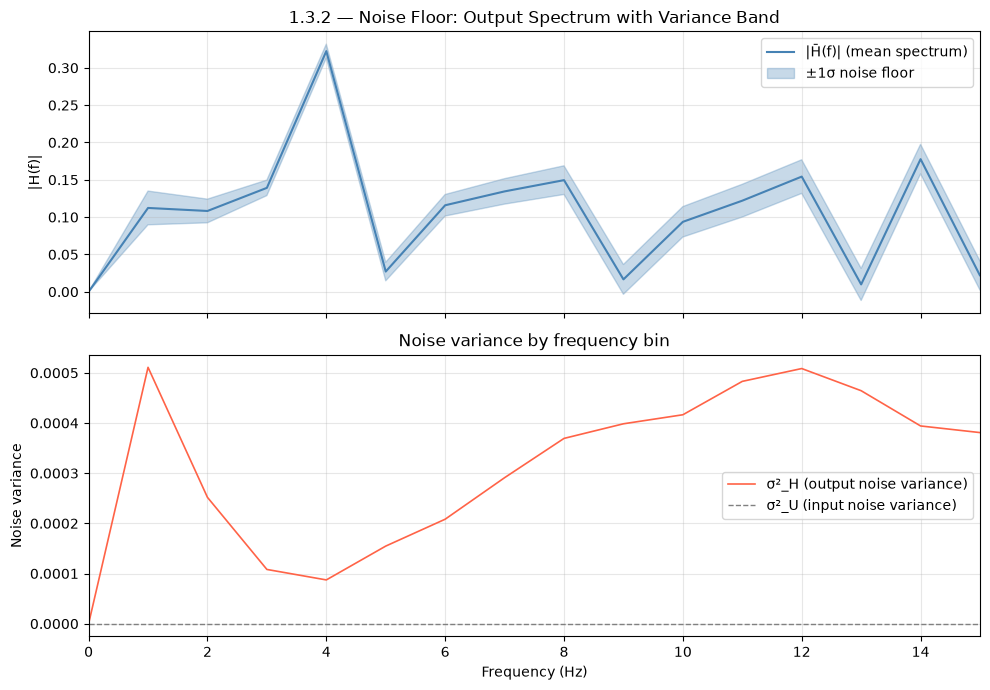

Peak output noise floor (σ²_H): 0.000511
Coherent distortion appears as peaks in |H̄(f)| that do NOT appear in σ²_H.
Noise appears as elevated σ²_H — it varies from period to period.


In [8]:
# ── 1.3.2 Noise Floor Analysis ─────────────────────────
# I/O convention:
#   u is scalar, shape (T_period,) per period
#   h used as scalar: h_scalar = ‖h‖₂
# Compare FFT spectra across N_PERIODS to separate coherent distortion from noise.

T_total = len(h_ms)
H_periods = []
U_periods = []

for p in range(N_PERIODS):
    start = p * T_period
    end   = start + T_period
    h_period_slice = h_ms[start:end]
    h_period_slice = h_period_slice - h_period_slice.mean()   # remove DC per period
    H_periods.append(np.fft.rfft(h_period_slice) / T_period)
    u_period_slice = u_ms[start:end]
    u_period_slice = u_period_slice - u_period_slice.mean()   # remove DC per period (symmetric treatment)
    U_periods.append(np.fft.rfft(u_period_slice) / T_period)

H_arr = np.array(H_periods)  # shape (N_PERIODS, T_period//2 + 1)
U_arr = np.array(U_periods)

H_mean = H_arr.mean(axis=0)
U_mean = U_arr.mean(axis=0)

# Per-frequency noise variance (variance across periods)
sigma2_H = (1 / (N_PERIODS - 1)) * np.sum(np.abs(H_arr - H_mean)**2, axis=0)
sigma2_U = (1 / (N_PERIODS - 1)) * np.sum(np.abs(U_arr - U_mean)**2, axis=0)

# ── Plot ──────────────────────────────────────────────
fig, axes = plt.subplots(2, 1, figsize=(10, 7), sharex=True)

axes[0].plot(freqs, np.abs(H_mean), color='steelblue', lw=1.5, label='|H̄(f)| (mean spectrum)')
axes[0].fill_between(freqs,
    np.abs(H_mean) - np.sqrt(sigma2_H),
    np.abs(H_mean) + np.sqrt(sigma2_H),
    alpha=0.3, color='steelblue', label='±1σ noise floor')
axes[0].set_ylabel("|H(f)|")
axes[0].set_title("1.3.2 — Noise Floor: Output Spectrum with Variance Band")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(freqs, sigma2_H, color='tomato', lw=1.2, label='σ²_H (output noise variance)')
axes[1].plot(freqs, sigma2_U, color='gray',   lw=1.0, label='σ²_U (input noise variance)', ls='--')
axes[1].set_xlabel("Frequency (Hz)")
axes[1].set_ylabel("Noise variance")
axes[1].set_title("Noise variance by frequency bin")
axes[1].legend()
axes[1].grid(True, alpha=0.3)
axes[1].set_xlim([0, 15])

plt.tight_layout()
plt.show()

noise_floor_peak = float(np.max(sigma2_H))
print(f"Peak output noise floor (σ²_H): {noise_floor_peak:.6f}")
print("Coherent distortion appears as peaks in |H̄(f)| that do NOT appear in σ²_H.")
print("Noise appears as elevated σ²_H — it varies from period to period.")

In [9]:
# ── Section 1 Results Summary ──────────────────────────

results_s1 = {
    "V_SAFE":             V_SAFE,
    "H_linear_power":     float(H_linear_power),
    "H_odd_power":        float(H_odd_power),
    "H_even_power":       float(H_even_power),
    "total_spectral_power": float(total_power),
    "noise_floor_peak_sigma2_H": noise_floor_peak,
    "DUT_params": LIESN_PARAMS,
}

os.makedirs(RESULTS_DIR, exist_ok=True)
with open(os.path.join(RESULTS_DIR, "section1_results.json"), "w") as f:
    json.dump(results_s1, f, indent=2)

print("=" * 50)
print("SECTION 1 RESULTS SUMMARY")
print("=" * 50)
print(f"  V_safe:              {V_SAFE:.3f}")
print(f"  H_linear power:      {H_linear_power:.4f}  ({100*H_linear_power/total_power:.1f}%)")
print(f"  H_odd power:         {H_odd_power:.4f}  ({100*H_odd_power/total_power:.1f}%)")
print(f"  H_even power:        {H_even_power:.4f}  ({100*H_even_power/total_power:.1f}%)")
print(f"  Peak noise floor:    {noise_floor_peak:.6f}")
print(f"\nResults saved to {RESULTS_DIR}section1_results.json")
print("\nProceed to Section 2 with the V_safe value above.")

SECTION 1 RESULTS SUMMARY
  V_safe:              0.800
  H_linear power:      0.0643  (22.0%)
  H_odd power:         0.0011  (0.4%)
  H_even power:        0.1618  (55.5%)
  Peak noise floor:    0.000511

Results saved to results/section1_results.json

Proceed to Section 2 with the V_safe value above.
